In [1]:
from pathlib import Path
import json
import pandas as pd

# adapte si besoin selon où est ton notebook
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

run_dir = PROJECT_ROOT / "evals" / "experiments" / "run_20260310_174748"

print("PROJECT_ROOT =", PROJECT_ROOT)
print("run_dir exists ?", run_dir.exists())
print("files in run_dir:", list(run_dir.glob("*")) if run_dir.exists() else "absent")

results_path = run_dir / "results.csv"
summary_path = run_dir / "summary.json"
traces_path = run_dir / "traces.jsonl"

df = pd.read_csv(results_path)

with open(summary_path, "r", encoding="utf-8") as f:
    summary = json.load(f)

traces = []
with open(traces_path, "r", encoding="utf-8") as f:
    for line in f:
        traces.append(json.loads(line))

traces_df = pd.DataFrame(traces)

print("Shape results:", df.shape)
print("Shape traces:", traces_df.shape)
df.head()

PROJECT_ROOT = C:\Users\thoma\Documents\Openclassroom\Projet-10
run_dir exists ? True
files in run_dir: [WindowsPath('C:/Users/thoma/Documents/Openclassroom/Projet-10/evals/experiments/run_20260310_174748/.~lock.results.csv#'), WindowsPath('C:/Users/thoma/Documents/Openclassroom/Projet-10/evals/experiments/run_20260310_174748/results.csv'), WindowsPath('C:/Users/thoma/Documents/Openclassroom/Projet-10/evals/experiments/run_20260310_174748/summary.json'), WindowsPath('C:/Users/thoma/Documents/Openclassroom/Projet-10/evals/experiments/run_20260310_174748/traces.jsonl')]
Shape results: (50, 23)
Shape traces: (50, 14)


,user_input,retrieved_contexts,response,reference,faithfulness,answer_relevancy,id,category,lang,expected_tool,...,expected_source_ids,reference_answer,hit_at_k,precision_at_k,recall_at_k,mrr,tool_call_accuracy_ragas,tool_call_f1_ragas,sql_query_equivalence_ragas,datacompy_score_ragas
0,Quels sont les avis exprimés sur l'équipe d'Or...,"[""Magic are down 3-1 despite injuring 3 Celtic...","D'après les discussions dans **Reddit 1.pdf**,...",Le fil décrit le Magic comme très faible au ti...,0.933333,0.813862,v1_001,text_lookup,fr,rag,...,['inputs/Reddit 1.pdf'],Le fil décrit le Magic comme très faible au ti...,1.0,0.2,1.0,1.0,NaN,NaN,NaN,NaN
1,"Dans Reddit 1, quels sont les deux jeunes joue...","[""pristine brand of basketball.\nRépondre\nNot...","D'après les discussions sur Reddit 1, les deux...",Paolo et Franz ; reproche principal : ils sont...,0.750000,0.777529,v1_002,text_lookup,fr,rag,...,['inputs/Reddit 1.pdf'],Paolo et Franz ; reproche principal : ils sont...,1.0,0.2,1.0,1.0,NaN,NaN,NaN,NaN
2,Quels avis sont donnés sur Julius Randle dans ...,"[""the Knicks were in the playoffs and everyone...",Voici les principaux avis sur Julius Randle ex...,"Il est présenté comme une révélation, une des ...",0.913043,0.937803,v1_003,text_lookup,fr,rag,...,['inputs/Reddit 1.pdf'],"Il est présenté comme une révélation, une des ...",1.0,0.2,1.0,1.0,NaN,NaN,NaN,NaN
3,Quels avis sont donnés sur les Timberwolves («...,"[""U 1\nRépondre\nréponse supplémentaire\nDawn_...","D'après les discussions sur Reddit 1, voici le...",Ils sont décrits comme élite en attaque et en ...,0.823529,0.958590,v1_004,text_lookup,fr,rag,...,['inputs/Reddit 1.pdf'],Ils sont décrits comme élite en attaque et en ...,1.0,0.2,1.0,1.0,NaN,NaN,NaN,NaN
4,Quels avis sont donnés sur Cade Cunningham (Pi...,"[""don't think that's really the issue: It's a ...","D'après les discussions sur Reddit 1, voici le...",Il est dit qu'il a prouvé qu'il était le bon c...,0.700000,0.869294,v1_005,text_lookup,fr,rag,...,['inputs/Reddit 1.pdf'],Il est dit qu'il a prouvé qu'il était le bon c...,1.0,0.2,1.0,1.0,NaN,NaN,NaN,NaN


In [6]:
metric_cols = [
    "faithfulness",
    "answer_relevancy",
    "hit_at_k",
    "mrr",
    "recall_at_k",
    "precision_at_k",
]

df[metric_cols].describe()

,faithfulness,answer_relevancy,hit_at_k,mrr,recall_at_k,precision_at_k
count,50.000000,50.000000,45.000000,45.000000,45.000000,45.000000
mean,0.530251,0.518936,0.444444,0.444444,0.344444,0.088889
std,0.354754,0.448263,0.502519,0.502519,0.424026,0.100504
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.170455,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.630682,0.819398,0.000000,0.000000,0.000000,0.000000
75%,0.849038,0.919425,1.000000,1.000000,0.500000,0.200000
max,1.000000,0.983091,1.000000,1.000000,1.000000,0.200000


In [5]:
df[metric_cols].mean(numeric_only=True).sort_values(ascending=False)

faithfulness        0.530251
answer_relevancy    0.518936
hit_at_k            0.444444
mrr                 0.444444
recall_at_k         0.344444
precision_at_k      0.088889
dtype: float64

In [7]:
category_stats = (
    df.groupby("category")[metric_cols]
      .mean(numeric_only=True)
      .sort_values("faithfulness")
)

category_stats

,faithfulness,answer_relevancy,hit_at_k,mrr,recall_at_k,precision_at_k
category,,,,,,
out_of_scope_or_unanswerable,0.323571,0.188037,NaN,NaN,NaN,NaN
numeric_compare,0.375594,0.469301,0.000000,0.000000,0.000000,0.000000
hybrid_text_plus_number,0.429424,0.443359,1.000000,1.000000,0.500000,0.200000
noisy_or_ambiguous,0.475425,0.679001,0.200000,0.200000,0.100000,0.040000
numeric_single,0.507363,0.275693,0.000000,0.000000,0.000000,0.000000
text_lookup,0.854385,0.884568,0.916667,0.916667,0.916667,0.183333


In [8]:
df["category"].value_counts()

category
text_lookup                     12
numeric_single                  10
numeric_compare                 10
hybrid_text_plus_number          8
noisy_or_ambiguous               5
out_of_scope_or_unanswerable     5
Name: count, dtype: int64

In [9]:
cols_to_show = [
    "id",
    "category",
    "question",
    "answer",
    "faithfulness",
    "answer_relevancy",
    "hit_at_k",
    "retrieved_source_ids",
    "expected_source_ids",
]

worst_faithfulness = df.sort_values("faithfulness").head(10)
worst_faithfulness[cols_to_show]

,id,category,question,answer,faithfulness,answer_relevancy,hit_at_k,retrieved_source_ids,expected_source_ids
15,v1_016,numeric_single,Quel est le joueur le plus jeune (Age) et quel...,"D'après les données disponibles, le joueur le ...",0.000000,0.928118,0.0,['regular NBA.xlsx (Feuille: Dictionnaire des ...,['inputs/regular NBA.xlsx (Feuille: Données NB...
31,v1_032,numeric_compare,Quels sont les 5 meilleurs marqueurs par minut...,"Pour répondre à votre question, je vais calcul...",0.000000,0.924223,0.0,['regular NBA.xlsx (Feuille: Dictionnaire des ...,['inputs/regular NBA.xlsx (Feuille: Données NB...
23,v1_024,numeric_compare,Quels sont les 10 meilleurs pourcentages à 3 p...,Voici les 10 meilleurs pourcentages de réussit...,0.000000,0.960752,0.0,['regular NBA.xlsx (Feuille: Dictionnaire des ...,['inputs/regular NBA.xlsx (Feuille: Données NB...
19,v1_020,numeric_single,Qui a le plus de passes décisives (AST) et com...,"D'après les données disponibles, le joueur ave...",0.000000,0.000000,0.0,['regular NBA.xlsx (Feuille: Dictionnaire des ...,['inputs/regular NBA.xlsx (Feuille: Données NB...
24,v1_025,numeric_compare,Quels sont les 10 meilleurs pourcentages à 3 p...,D'après les données disponibles dans le fichie...,0.000000,0.951766,0.0,"['regular NBA.xlsx (Feuille: Analyse)', 'regul...",['inputs/regular NBA.xlsx (Feuille: Données NB...
49,v1_050,out_of_scope_or_unanswerable,Donne-moi le lien vers la vidéo du meilleur du...,Je ne peux pas fournir directement des liens v...,0.000000,0.000000,NaN,"['regular NBA.xlsx (Feuille: Equipe)', 'Reddit...",[]
41,v1_042,noisy_or_ambiguous,Quel Curry a le meilleur pourcentage à 3 points ?,La question du meilleur pourcentage à 3 points...,0.000000,0.889440,0.0,"['Reddit 3.pdf', 'Reddit 3.pdf', 'Reddit 3.pdf...",['inputs/regular NBA.xlsx (Feuille: Données NB...
46,v1_047,out_of_scope_or_unanswerable,Compare les statistiques de rebonds de l'équip...,Pour comparer les statistiques de rebonds des ...,0.000000,0.940183,NaN,['regular NBA.xlsx (Feuille: Dictionnaire des ...,[]
26,v1_027,numeric_compare,Quels sont les 5 meilleurs Net Rating (NETRTG)...,"Pour répondre à votre question, je vais analys...",0.037037,0.000000,0.0,['regular NBA.xlsx (Feuille: Dictionnaire des ...,['inputs/regular NBA.xlsx (Feuille: Données NB...
48,v1_049,out_of_scope_or_unanswerable,Quels joueurs ont changé d'équipe en cours de ...,"D'après les données disponibles, je ne peux pa...",0.100000,0.000000,NaN,"['regular NBA.xlsx (Feuille: Equipe)', 'regula...",[]


In [10]:
worst_relevancy = df.sort_values("answer_relevancy").head(10)
worst_relevancy[cols_to_show]

,id,category,question,answer,faithfulness,answer_relevancy,hit_at_k,retrieved_source_ids,expected_source_ids
13,v1_014,numeric_single,Qui a réalisé le plus de contres (BLK) et comb...,"D'après les données disponibles, la feuille ""D...",0.750000,0.0,0.0,['regular NBA.xlsx (Feuille: Dictionnaire des ...,['inputs/regular NBA.xlsx (Feuille: Données NB...
14,v1_015,numeric_single,Quel est le joueur le plus âgé (Age) et quel â...,D'après les données disponibles dans le fichie...,0.625000,0.0,0.0,['regular NBA.xlsx (Feuille: Dictionnaire des ...,['inputs/regular NBA.xlsx (Feuille: Données NB...
29,v1_030,numeric_compare,Quel est l'écart de points (PTS) entre le meil...,"D'après les données disponibles, nous pouvons ...",0.714286,0.0,0.0,"['regular NBA.xlsx (Feuille: Analyse Vide)', '...",['inputs/regular NBA.xlsx (Feuille: Données NB...
21,v1_022,numeric_single,Qui a commis le plus de pertes de balle (TOV) ...,D'après les données disponibles dans le fichie...,0.850000,0.0,0.0,['regular NBA.xlsx (Feuille: Dictionnaire des ...,['inputs/regular NBA.xlsx (Feuille: Données NB...
20,v1_021,numeric_single,Qui a réalisé le plus d'interceptions (STL) et...,"D'après les données disponibles, je ne peux pa...",1.000000,0.0,0.0,['regular NBA.xlsx (Feuille: Dictionnaire des ...,['inputs/regular NBA.xlsx (Feuille: Données NB...
19,v1_020,numeric_single,Qui a le plus de passes décisives (AST) et com...,"D'après les données disponibles, le joueur ave...",0.000000,0.0,0.0,['regular NBA.xlsx (Feuille: Dictionnaire des ...,['inputs/regular NBA.xlsx (Feuille: Données NB...
28,v1_029,numeric_compare,"Parmi les 10 meilleurs marqueurs (top 10 PTS),...","Pour répondre à cette question, nous devons id...",0.636364,0.0,0.0,['regular NBA.xlsx (Feuille: Dictionnaire des ...,['inputs/regular NBA.xlsx (Feuille: Données NB...
30,v1_031,numeric_compare,Quelle est la moyenne de points (PTS) des 10 m...,"D'après les données disponibles, nous pouvons ...",0.714286,0.0,0.0,"['regular NBA.xlsx (Feuille: Analyse Vide)', '...",['inputs/regular NBA.xlsx (Feuille: Données NB...
27,v1_028,numeric_compare,"Parmi les 10 meilleurs marqueurs (top 10 PTS),...","D'après les données disponibles, l'analyse du ...",0.777778,0.0,0.0,['regular NBA.xlsx (Feuille: Dictionnaire des ...,['inputs/regular NBA.xlsx (Feuille: Données NB...
26,v1_027,numeric_compare,Quels sont les 5 meilleurs Net Rating (NETRTG)...,"Pour répondre à votre question, je vais analys...",0.037037,0.0,0.0,['regular NBA.xlsx (Feuille: Dictionnaire des ...,['inputs/regular NBA.xlsx (Feuille: Données NB...


In [11]:
df[["hit_at_k", "mrr", "recall_at_k", "precision_at_k", "faithfulness", "answer_relevancy"]].corr()

,hit_at_k,mrr,recall_at_k,precision_at_k,faithfulness,answer_relevancy
hit_at_k,1.000000,1.000000,0.918463,1.000000,0.341614,0.307066
mrr,1.000000,1.000000,0.918463,1.000000,0.341614,0.307066
recall_at_k,0.918463,0.918463,1.000000,0.918463,0.455576,0.405191
precision_at_k,1.000000,1.000000,0.918463,1.000000,0.341614,0.307066
faithfulness,0.341614,0.341614,0.455576,0.341614,1.000000,-0.072468
answer_relevancy,0.307066,0.307066,0.405191,0.307066,-0.072468,1.000000


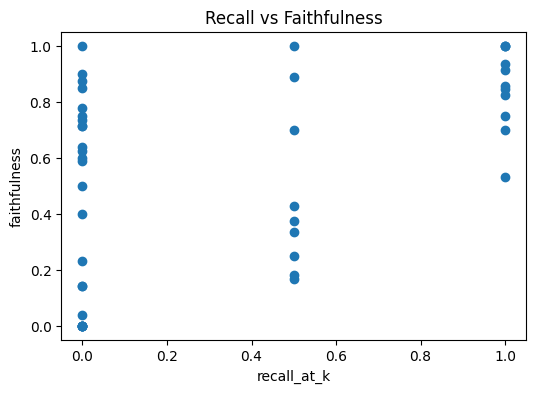

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.scatter(df["recall_at_k"], df["faithfulness"])
plt.xlabel("recall_at_k")
plt.ylabel("faithfulness")
plt.title("Recall vs Faithfulness")
plt.show()

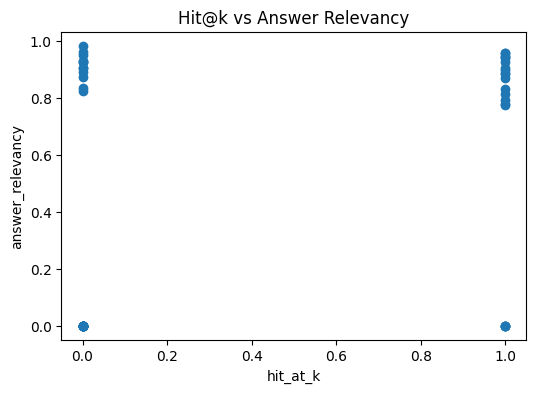

In [16]:
plt.figure(figsize=(6, 4))
plt.scatter(df["hit_at_k"], df["answer_relevancy"])
plt.xlabel("hit_at_k")
plt.ylabel("answer_relevancy")
plt.title("Hit@k vs Answer Relevancy")
plt.show()

In [14]:
out_of_scope_keywords = [
    "5 derniers matchs",
    "dernier match",
    "transferts",
    "vidéo",
    "à domicile et à l'extérieur",
]

def detect_out_of_scope(q: str) -> bool:
    q = str(q).lower()
    return any(k.lower() in q for k in out_of_scope_keywords)

df["is_out_of_scope"] = df["question"].apply(detect_out_of_scope)
df.groupby("is_out_of_scope")[metric_cols].mean(numeric_only=True)

,faithfulness,answer_relevancy,hit_at_k,mrr,recall_at_k,precision_at_k
is_out_of_scope,,,,,,
False,0.553215,0.555703,0.444444,0.444444,0.344444,0.088889
True,0.323571,0.188037,NaN,NaN,NaN,NaN
